# Linear Regression

In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

In [2]:
import statsmodels.api as sm

In [3]:
from statsmodels.stats.outliers_influence\
import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

In [4]:
%pip install ISLP -q

Note: you may need to restart the kernel to use updated packages.


In [5]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,summarize,poly)

In [6]:
#dir()

In [7]:
A = np.array([3,5,11])
dir(A)

['T',
 '__abs__',
 '__add__',
 '__and__',
 '__array__',
 '__array_finalize__',
 '__array_function__',
 '__array_interface__',
 '__array_namespace__',
 '__array_priority__',
 '__array_struct__',
 '__array_ufunc__',
 '__array_wrap__',
 '__bool__',
 '__buffer__',
 '__class__',
 '__class_getitem__',
 '__complex__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__divmod__',
 '__dlpack__',
 '__dlpack_device__',
 '__doc__',
 '__eq__',
 '__float__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__ilshift__',
 '__imatmul__',
 '__imod__',
 '__imul__',
 '__index__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__irshift__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lshift__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__mul__',
 '__ne__',
 '__neg__',


In [8]:
A.sum()

np.int64(19)

# Simple Linear Regression

In [9]:
Boston = load_data("Boston")
Boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

In [10]:
X = pd.DataFrame({'intercept': np.ones(Boston.shape[0]),
'lstat': Boston['lstat']})
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [11]:
y = Boston['medv']
model = sm.OLS(y, X)
results = model.fit()

In [12]:
summarize(results)

,coef,std err,t,P>|t|
intercept,34.5538,0.563,61.415,0.0
lstat,-0.9500,0.039,-24.528,0.0


# Using Transformations: Fit and Transform

In [13]:
design = MS(['lstat'])
design = design.fit(Boston)
X = design.transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [14]:
design = MS(['lstat'])
X = design.fit_transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [15]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Tue, 18 Aug 2026   Prob (F-statistic):           5.08e-88
Time:                        16:49:29   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [16]:
results.params

intercept    34.553841
lstat        -0.950049
dtype: float64

In [17]:
new_df = pd.DataFrame({'lstat':[5, 10, 15]})
newX = design.transform(new_df)
newX

,intercept,lstat
0,1.0,5
1,1.0,10
2,1.0,15


In [18]:
new_predictions = results.get_prediction(newX);
new_predictions.predicted_mean

array([29.80359411, 25.05334734, 20.30310057])

In [19]:
 new_predictions.conf_int(alpha=0.05)

array([[29.00741194, 30.59977628],
       [24.47413202, 25.63256267],
       [19.73158815, 20.87461299]])

In [20]:
 new_predictions.conf_int(obs=True, alpha=0.05)

array([[17.56567478, 42.04151344],
       [12.82762635, 37.27906833],
       [ 8.0777421 , 32.52845905]])

# Defining Functions

In [21]:
def abline(ax, b, m):
#"Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim)

In [22]:
def abline(ax, b, m, *args, **kwargs):
#"Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

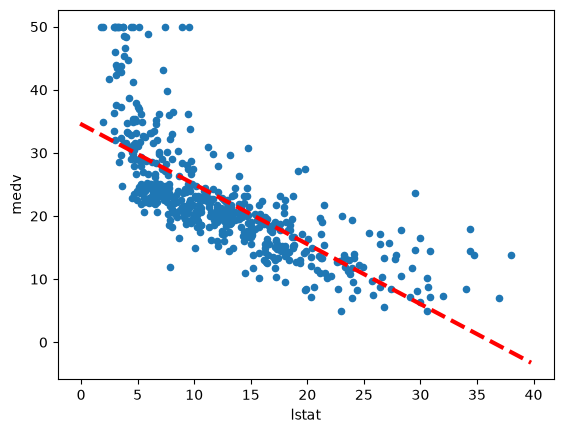

In [23]:
ax = Boston.plot.scatter('lstat', 'medv')

abline(ax,
       results.params.iloc[0],
       results.params.iloc[1],
       'r--',
       linewidth=3)

In [24]:
#ax = Boston.plot.scatter('lstat', 'medv')

#abline(ax,
       #results.params['const'],
       #results.params['lstat'],
       #'r--',
       #linewidth=3)

# Diagnostic Plot

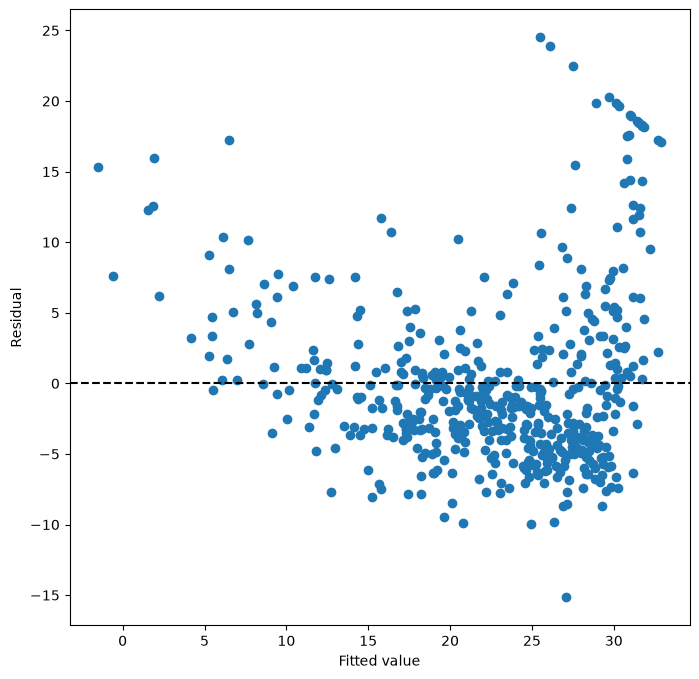

In [25]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

np.int64(374)

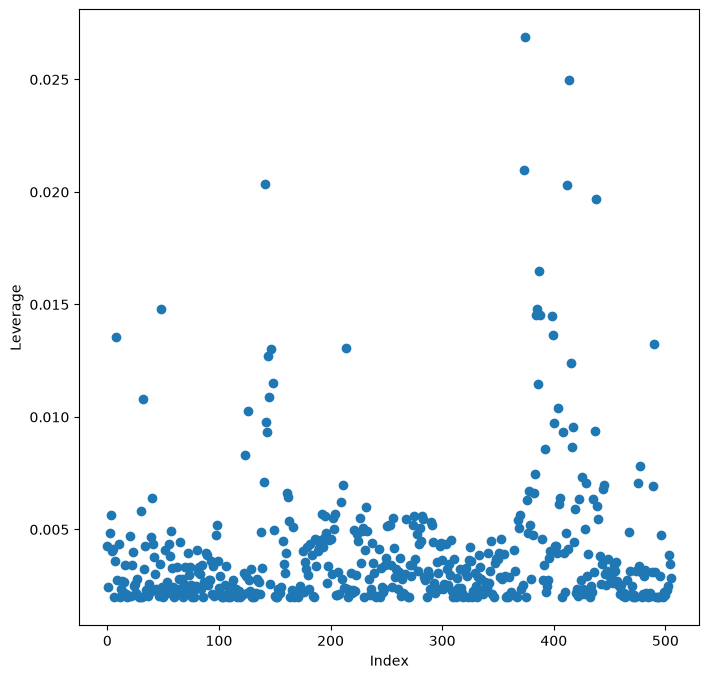

In [26]:
infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

# Multiple Linear Regression

In [27]:
X = MS(['lstat', 'age']).fit_transform(Boston)
model1 = sm.OLS(y, X)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
intercept,33.2228,0.731,45.458,0.000
lstat,-1.0321,0.048,-21.416,0.000
age,0.0345,0.012,2.826,0.005


In [28]:
terms = Boston.columns.drop('medv')
terms

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat'],
      dtype='object')

In [29]:
X = MS(terms).fit_transform(Boston)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,41.6173,4.936,8.431,0.000
crim,-0.1214,0.033,-3.678,0.000
zn,0.0470,0.014,3.384,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8400,0.870,3.264,0.001
nox,-18.7580,3.851,-4.870,0.000
rm,3.6581,0.420,8.705,0.000
age,0.0036,0.013,0.271,0.787
dis,-1.4908,0.202,-7.394,0.000
rad,0.2894,0.067,4.325,0.000


In [30]:
minus_age = Boston.columns.drop(['medv', 'age'])
Xma = MS(minus_age).fit_transform(Boston)
model1 = sm.OLS(y, Xma)
summarize(model1.fit())

,coef,std err,t,P>|t|
intercept,41.5251,4.920,8.441,0.000
crim,-0.1214,0.033,-3.683,0.000
zn,0.0465,0.014,3.379,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8528,0.868,3.287,0.001
nox,-18.4851,3.714,-4.978,0.000
rm,3.6811,0.411,8.951,0.000
dis,-1.5068,0.193,-7.825,0.000
rad,0.2879,0.067,4.322,0.000
tax,-0.0127,0.004,-3.333,0.001


# Multivariate Goodnessof Fit

# List Comprehension

In [31]:
vals = [VIF(X, i)
for i in range(1, X.shape[1])]
vif = pd.DataFrame({'vif':vals},
index=X.columns[1:])
vif

,vif
crim,1.767486
zn,2.298459
indus,3.987181
chas,1.071168
nox,4.369093
rm,1.912532
age,3.088232
dis,3.954037
rad,7.445301
tax,9.002158


In [32]:
vals = []
for i in range(1, X.values.shape[1]):
    vals.append(VIF(X.values, i))

In [33]:
X = MS(['lstat',
        'age',
        ('lstat', 'age')]).fit_transform(Boston)
model2 = sm.OLS(y, X)
summarize(model2.fit())

,coef,std err,t,P>|t|
intercept,36.0885,1.470,24.553,0.000
lstat,-1.3921,0.167,-8.313,0.000
age,-0.0007,0.020,-0.036,0.971
lstat:age,0.0042,0.002,2.244,0.025


# Non-linear Transformations of the Predictors

In [34]:
X = MS([poly('lstat', degree=2), 'age']).fit_transform(Boston)
model3 = sm.OLS(y, X)
results3 = model3.fit()
summarize(results3)

,coef,std err,t,P>|t|
intercept,17.7151,0.781,22.681,0.0
"poly(lstat, degree=2)[0]",-179.2279,6.733,-26.620,0.0
"poly(lstat, degree=2)[1]",72.9908,5.482,13.315,0.0
age,0.0703,0.011,6.471,0.0


In [35]:
anova_lm(results1, results3)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,503.0,19168.128609,0.0,NaN,NaN,NaN
1,502.0,14165.613251,1.0,5002.515357,177.278785,7.468491e-35


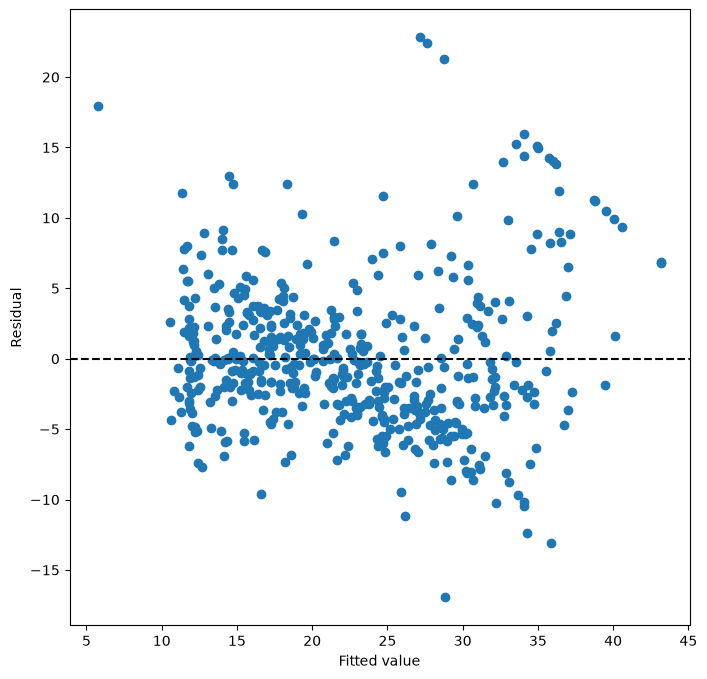

In [36]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results3.fittedvalues, results3.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')

# Qualitative Predictors

In [37]:
Carseats = load_data('Carseats')
Carseats.columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

In [38]:
allvars = list(Carseats.columns.drop('Sales'))
y = Carseats['Sales']
final = allvars + [('Income', 'Advertising'),
('Price', 'Age')]
X = MS(final).fit_transform(Carseats)
model = sm.OLS(y, X)
summarize(model.fit())

,coef,std err,t,P>|t|
intercept,6.5756,1.009,6.519,0.000
CompPrice,0.0929,0.004,22.567,0.000
Income,0.0109,0.003,4.183,0.000
Advertising,0.0702,0.023,3.107,0.002
Population,0.0002,0.000,0.433,0.665
Price,-0.1008,0.007,-13.549,0.000
ShelveLoc[Good],4.8487,0.153,31.724,0.000
ShelveLoc[Medium],1.9533,0.126,15.531,0.000
Age,-0.0579,0.016,-3.633,0.000
Education,-0.0209,0.020,-1.063,0.288


# End of Lab 1

# Chapter Two : Question 9

In [39]:
from ISLP import load_data

Auto = load_data("Auto")

print(Auto.shape)
Auto.head()

(392, 8)


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


# Replace '?' with missing values

In [40]:
Auto = Auto.replace("?", np.nan)


In [41]:
# Convert horsepower to numeric
Auto["horsepower"] = pd.to_numeric(Auto["horsepower"])

In [42]:
# Remove missing observations
Auto = Auto.dropna().reset_index(drop=True)

In [43]:
print("Dimensions:", Auto.shape)
print(Auto.head())

Dimensions: (392, 8)
    mpg  cylinders  displacement  horsepower  weight  acceleration  year  \
0  18.0          8         307.0         130    3504          12.0    70   
1  15.0          8         350.0         165    3693          11.5    70   
2  18.0          8         318.0         150    3436          11.0    70   
3  16.0          8         304.0         150    3433          12.0    70   
4  17.0          8         302.0         140    3449          10.5    70   

   origin  
0       1  
1       1  
2       1  
3       1  
4       1  


# ---------------------------------------------------------
# 2. Identify quantitative variables
# ---------------------------------------------------------

In [44]:
quantitative = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "year"
]

qualitative = [
    "origin",
    "name"
]

print("\nQuantitative variables:")
print(quantitative)

print("\nQualitative variables:")
print(qualitative)


Quantitative variables:
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year']

Qualitative variables:
['origin', 'name']


# ---------------------------------------------------------
# 3. Range
# ---------------------------------------------------------

In [45]:

ranges = Auto[quantitative].agg(["min", "max"]).T

print("\nRanges:")
print(ranges)


Ranges:
                 min     max
mpg              9.0    46.6
cylinders        3.0     8.0
displacement    68.0   455.0
horsepower      46.0   230.0
weight        1613.0  5140.0
acceleration     8.0    24.8
year            70.0    82.0


# ---------------------------------------------------------
# 4. Mean and standard deviation
# ---------------------------------------------------------

In [46]:

statistics = Auto[quantitative].agg(
    ["mean", "std"]
).T

print("\nMean and Standard Deviation:")
print(statistics)


Mean and Standard Deviation:
                     mean         std
mpg             23.445918    7.805007
cylinders        5.471939    1.705783
displacement   194.411990  104.644004
horsepower     104.469388   38.491160
weight        2977.584184  849.402560
acceleration    15.541327    2.758864
year            75.979592    3.683737


# ---------------------------------------------------------
# 5. Remove observations 10 through 85
#    R's 10:85 corresponds to Python positions 9:85
# ---------------------------------------------------------


In [47]:

Auto_2 = Auto.drop(Auto.index[9:85])

print("\nRemaining observations:", len(Auto_2))

subset_statistics = Auto_2[quantitative].agg(
    ["min", "max", "mean", "std"]
).T

print("\nStatistics after removing observations 10--85:")
print(subset_statistics)


Remaining observations: 316

Statistics after removing observations 10--85:
                 min     max         mean         std
mpg             11.0    46.6    24.404430    7.867283
cylinders        3.0     8.0     5.373418    1.654179
displacement    68.0   455.0   187.240506   99.678367
horsepower      46.0   230.0   100.721519   35.708853
weight        1649.0  4997.0  2935.971519  811.300208
acceleration     8.5    24.8    15.726899    2.693721
year            70.0    82.0    77.145570    3.106217


# ---------------------------------------------------------
# 6. Scatterplot matrix
# ---------------------------------------------------------

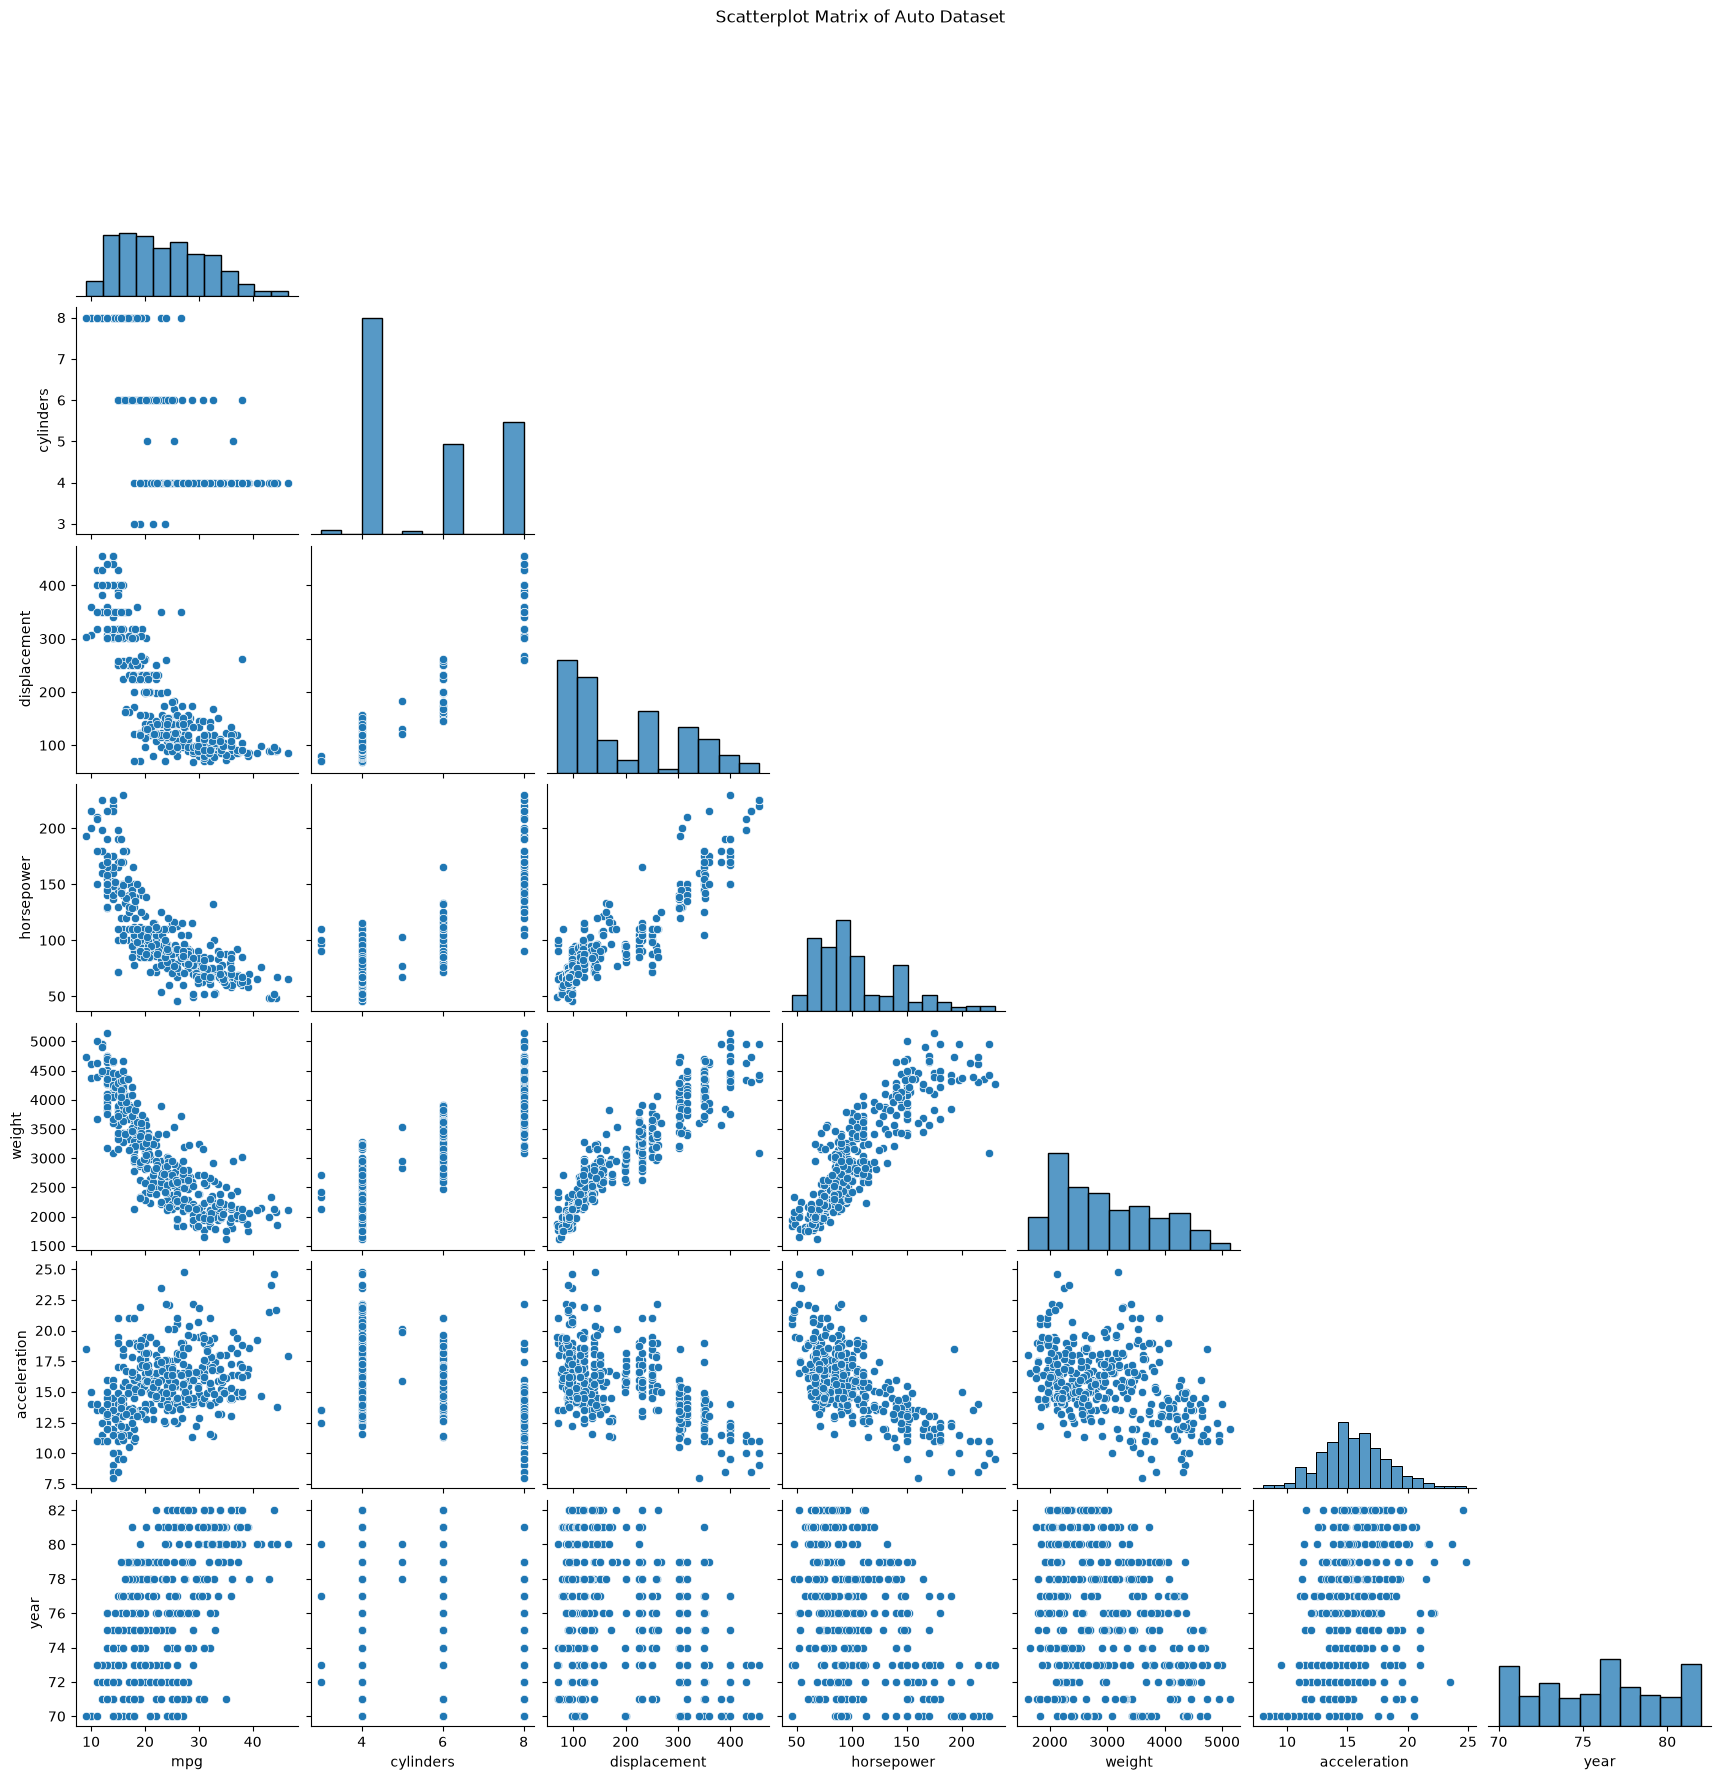

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(
    Auto,
    vars=quantitative,
    corner=True
)

plt.suptitle(
    "Scatterplot Matrix of Auto Dataset",
    y=1.02
)

plt.show()

# ---------------------------------------------------------
# 7. Correlation matrix
# ---------------------------------------------------------

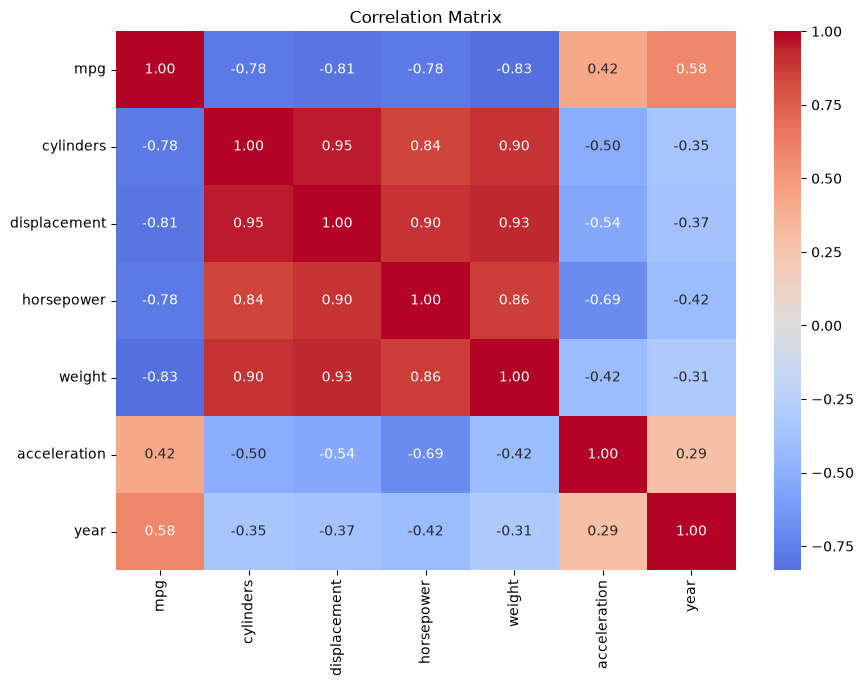

In [49]:


correlation_matrix = Auto[quantitative].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

# ---------------------------------------------------------
# 8. Weight vs MPG
# ---------------------------------------------------------

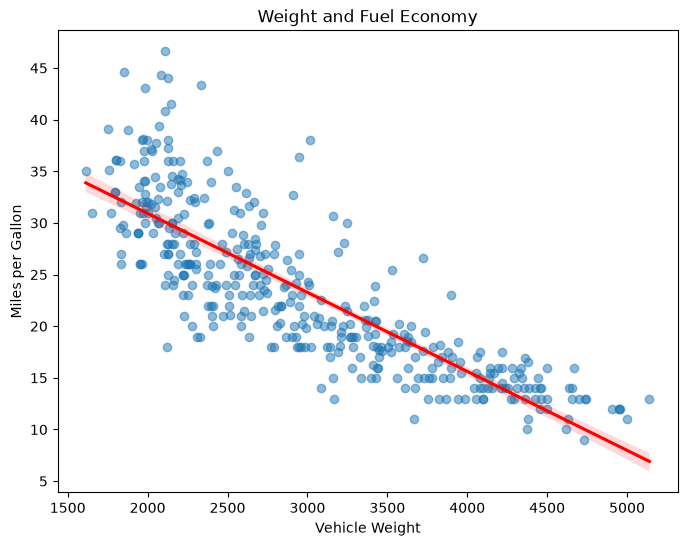

In [50]:

plt.figure(figsize=(8, 6))

sns.regplot(
    data=Auto,
    x="weight",
    y="mpg",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

plt.title("Weight and Fuel Economy")
plt.xlabel("Vehicle Weight")
plt.ylabel("Miles per Gallon")

plt.show()

# ---------------------------------------------------------
# 9. Horsepower vs MPG
# ---------------------------------------------------------

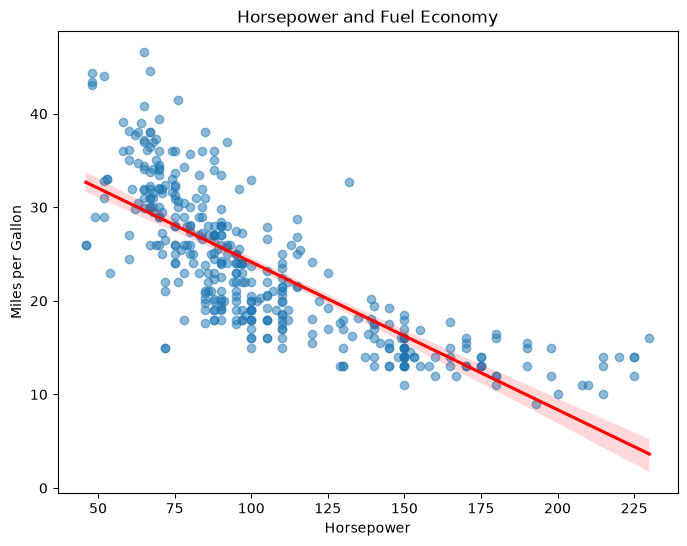

In [51]:


plt.figure(figsize=(8, 6))

sns.regplot(
    data=Auto,
    x="horsepower",
    y="mpg",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

plt.title("Horsepower and Fuel Economy")
plt.xlabel("Horsepower")
plt.ylabel("Miles per Gallon")

plt.show()

# ---------------------------------------------------------
# 10. MPG by cylinders
# ---------------------------------------------------------

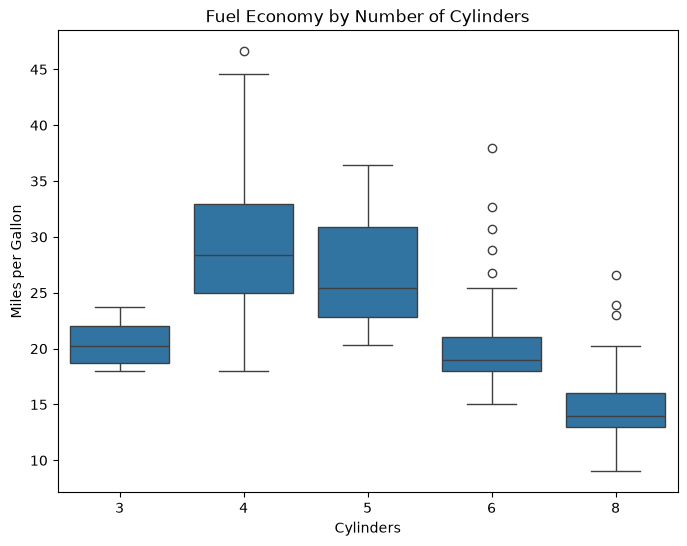

In [52]:


plt.figure(figsize=(8, 6))

sns.boxplot(
    data=Auto,
    x="cylinders",
    y="mpg"
)

plt.title("Fuel Economy by Number of Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("Miles per Gallon")

plt.show()

# ---------------------------------------------------------
# 11. MPG by origin
# ---------------------------------------------------------

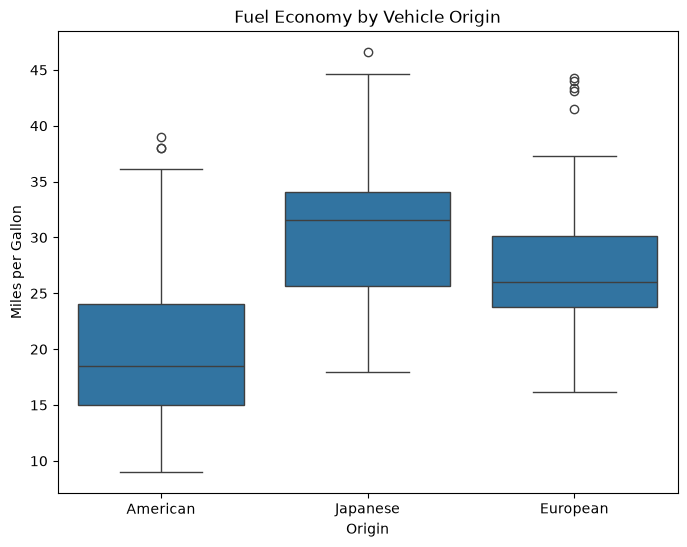

In [53]:


origin_labels = {
    1: "American",
    2: "European",
    3: "Japanese"
}

Auto_plot = Auto.copy()
Auto_plot["origin_label"] = Auto_plot["origin"].map(origin_labels)

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=Auto_plot,
    x="origin_label",
    y="mpg"
)

plt.title("Fuel Economy by Vehicle Origin")
plt.xlabel("Origin")
plt.ylabel("Miles per Gallon")

plt.show()

# ---------------------------------------------------------
# 12. MPG and year
# ---------------------------------------------------------

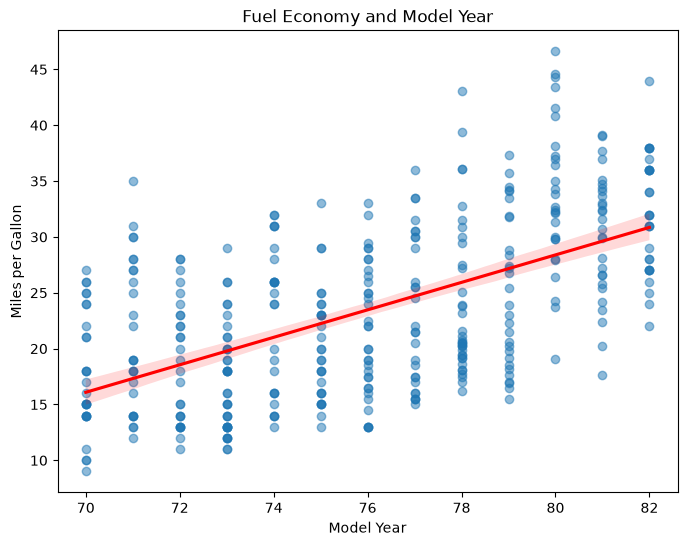

In [54]:


plt.figure(figsize=(8, 6))

sns.regplot(
    data=Auto,
    x="year",
    y="mpg",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

plt.title("Fuel Economy and Model Year")
plt.xlabel("Model Year")
plt.ylabel("Miles per Gallon")

plt.show()

# Chapter Three: Question 12 b.

# Generate random mumbers

In [56]:
np.random.seed(1)
n = 100
X = np.random.normal(0, 1, n)

# Generate error term

In [57]:
epsilon = np.random.normal(0, 1, n)

In [ ]:
# Generate Y (Regression)

In [ ]:
Y = 2 * X + epsilon

# Regression of Y onto X without intercept

In [58]:
Beta_Y_on_X = np.sum(X * Y) / np.sum(X**2)

# Regression of X onto Y without intercept

In [59]:
Beta_X_on_Y = np.sum(X * Y) / np.sum(Y**2)

In [61]:
print("Coefficient for Y onto X:", Beta_Y_on_X)
print("Coefficient for X onto Y:", Beta_X_on_Y)

print("Sum of X squared:", np.sum(X**2))
print("Sum of Y squared:", np.sum(Y**2))

Coefficient for Y onto X: 2.106741688959115
Coefficient for X onto Y: 0.37890442290720183
Sum of X squared: 78.71718048502926
Sum of Y squared: 437.67439950350075


# Chapter Three: Question 12 c.

In [62]:


np.random.seed(10)

n = 100

# Generate X
X = np.random.normal(0, 1, n)

# Make Y equal to X
Y = X.copy()

# Regression of Y onto X without intercept
beta_Y_on_X = np.sum(X * Y) / np.sum(X**2)

# Regression of X onto Y without intercept
beta_X_on_Y = np.sum(X * Y) / np.sum(Y**2)

print("Coefficient for Y onto X:", beta_Y_on_X)
print("Coefficient for X onto Y:", beta_X_on_Y)

print("Sum of X squared:", np.sum(X**2))
print("Sum of Y squared:", np.sum(Y**2))

Coefficient for Y onto X: 1.0
Coefficient for X onto Y: 1.0
Sum of X squared: 94.14723566483785
Sum of Y squared: 94.14723566483785
